In [16]:
import pandas as pd
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# 1. Load the EXTERNAL dataset
df = pd.read_csv("YoungvsOld_DEG_rlog_counts.csv", encoding='utf-8-sig')
gene_ids = df.iloc[:, 0]
data = df.iloc[:, 1:]

In [18]:
# 2. Scale
scaled_data = StandardScaler().fit_transform(data)

In [19]:
# 3. Apply the FIXED UMAP parameters 
embedding = umap.UMAP(
    n_neighbors=10, 
    min_dist=0.1, 
    metric='euclidean', 
    random_state=42
).fit_transform(scaled_data)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [20]:
# 4. Apply the FIXED k=56
kmeans_model = KMeans(
    n_clusters=56, 
    init='k-means++', 
    n_init=10, 
    random_state=42
)
labels = kmeans_model.fit_predict(embedding)

In [21]:
# 5. Metrics for the Rebuttal
sil = silhouette_score(embedding, labels)
cal = calinski_harabasz_score(embedding, labels)
db = davies_bouldin_score(embedding, labels)

print("--- EXTERNAL VALIDATION RESULTS (FIXED PARAMS) ---")
print(f"Silhouette Score       : {sil:.3f}")
print(f"Calinski-Harabasz Score: {cal:.3f}")
print(f"Davies-Bouldin Score   : {db:.3f}")

--- EXTERNAL VALIDATION RESULTS (FIXED PARAMS) ---
Silhouette Score       : 0.567
Calinski-Harabasz Score: 27014.683
Davies-Bouldin Score   : 0.538


In [22]:
# 6. Save for the final LMC check
val_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
val_df['Cluster'] = labels
val_df['GeneID'] = gene_ids.values
val_df.to_csv("external_fixed_clusters.csv", index=False)

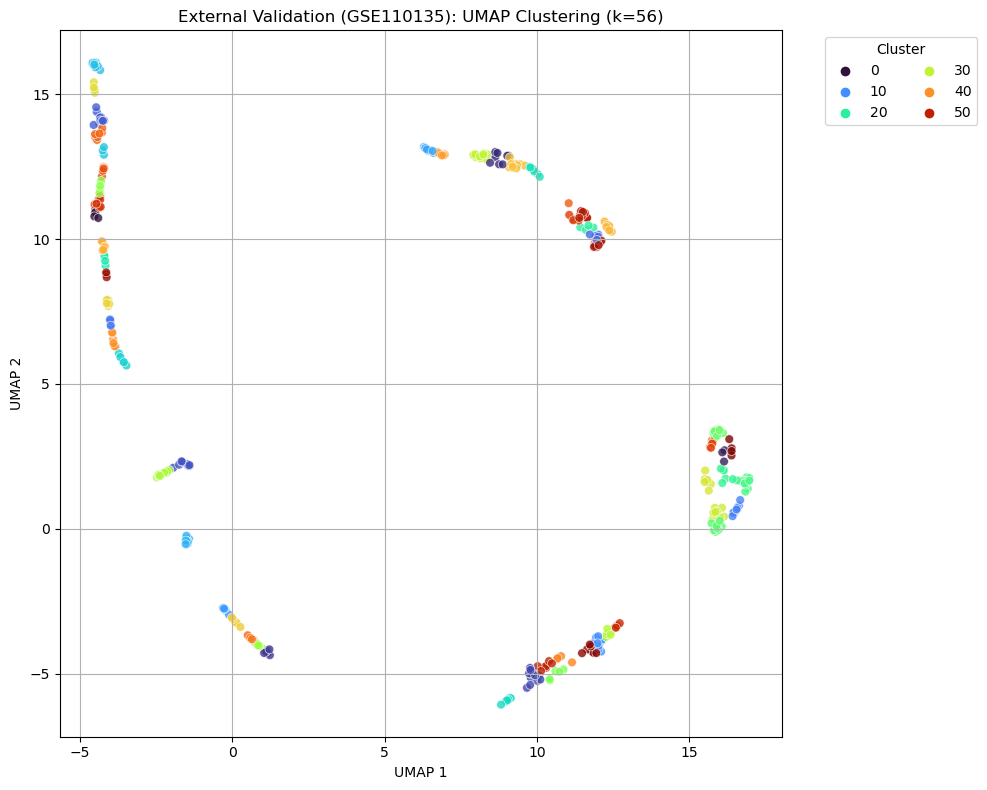

In [23]:
# 7. Visualization for Supplementary Figure
plot_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
plot_df['Cluster'] = labels

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='UMAP1', y='UMAP2',
    hue='Cluster',
    palette='turbo', # Consistent with your updated ORI plots
    data=plot_df,
    s=40,
    alpha=0.8
)

plt.title("External Validation (GSE110135): UMAP Clustering (k=56)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("Supplementary_Fig_External_UMAP.png", dpi=300)
plt.show()